In [2]:
from sklearn.datasets import load_wine

wine = load_wine()

X = wine.data
y = wine.target

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (178, 13)
y shape: (178,)


In [3]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

print("Scaled shape:", X_scaled.shape)

Scaled shape: (178, 13)


In [14]:
# we havent mentioned how much PC axis we need so it would give same as original data here 
from sklearn.decomposition import PCA

pca = PCA()

X_pca = pca.fit_transform(X_scaled)

print("Original shape:", X_scaled.shape)
print("PCA shape:", X_pca.shape)

Original shape: (178, 13)
PCA shape: (178, 13)


In [5]:
print(pca.explained_variance_ratio_)

[0.36198848 0.1920749  0.11123631 0.0706903  0.06563294 0.04935823
 0.04238679 0.02680749 0.02222153 0.01930019 0.01736836 0.01298233
 0.00795215]


In [6]:
import numpy as np

cumulative_variance = np.cumsum(
    pca.explained_variance_ratio_
)

print(cumulative_variance)

[0.36198848 0.55406338 0.66529969 0.73598999 0.80162293 0.85098116
 0.89336795 0.92017544 0.94239698 0.96169717 0.97906553 0.99204785
 1.        ]


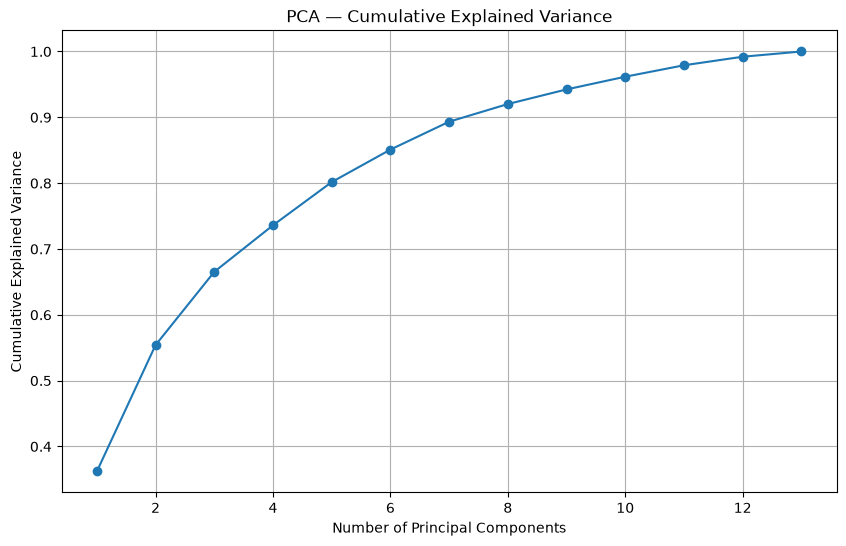

In [7]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

plt.plot(
    range(1, len(cumulative_variance) + 1),
    cumulative_variance,
    marker='o'
)

plt.xlabel("Number of Principal Components")
plt.ylabel("Cumulative Explained Variance")
plt.title("PCA — Cumulative Explained Variance")

plt.grid()
plt.show()

In [8]:
# suppose we need to preserve 0.95 varience
n_components = np.argmax(
    cumulative_variance >= 0.95
) + 1

print("Components needed:", n_components)

Components needed: 10


In [9]:
# If our goal is visualization, we often want
# we need two dimensional
pca_2d = PCA(n_components=2)

X_pca_2d = pca_2d.fit_transform(X_scaled)

print("Original shape:", X_scaled.shape)
print("Reduced shape:", X_pca_2d.shape)

Original shape: (178, 13)
Reduced shape: (178, 2)


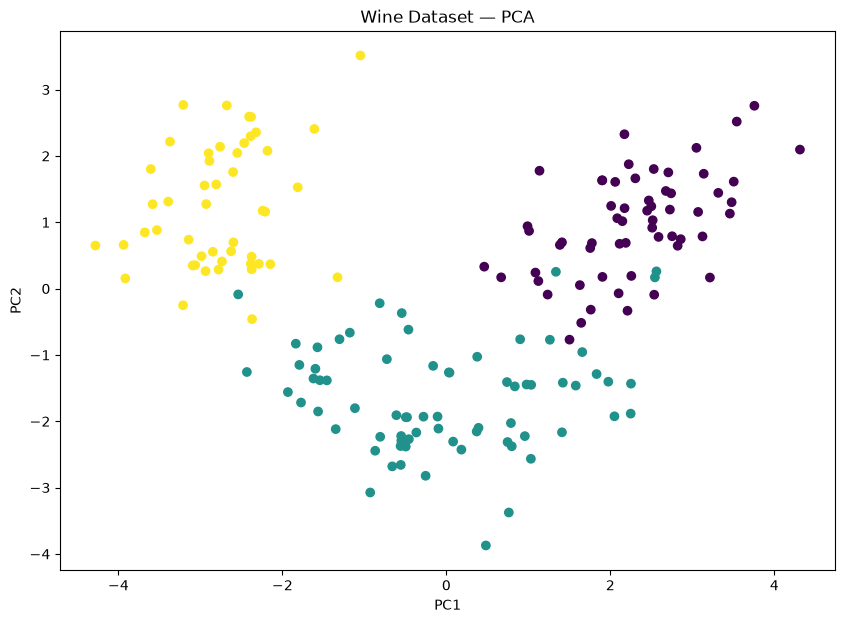

In [10]:
plt.figure(figsize=(10, 7))

plt.scatter(
    X_pca_2d[:, 0],
    X_pca_2d[:, 1],
    c=y
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("Wine Dataset — PCA")
plt.show()

In [11]:
print(pca_2d.components_)

[[ 0.1443294  -0.24518758 -0.00205106 -0.23932041  0.14199204  0.39466085
   0.4229343  -0.2985331   0.31342949 -0.0886167   0.29671456  0.37616741
   0.28675223]
 [ 0.48365155  0.22493093  0.31606881 -0.0105905   0.299634    0.06503951
  -0.00335981  0.02877949  0.03930172  0.52999567 -0.27923515 -0.16449619
   0.36490283]]


In [13]:
print(pca_2d.components_.shape)

(2, 13)


In [33]:
# comparison with the logistic regression without and with PCA

In [34]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

wine = load_wine()

X = wine.data
y = wine.target

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [35]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [36]:
model = LogisticRegression(max_iter=1000)

model.fit(X_train_scaled, y_train)

y_pred = model.predict(X_test_scaled)

accuracy = accuracy_score(y_test, y_pred)

print("Accuracy without PCA:", accuracy)

Accuracy without PCA: 0.9722222222222222


In [40]:
from sklearn.decomposition import PCA

pca = PCA(n_components=5)

X_train_pca = pca.fit_transform(X_train_scaled)
X_test_pca = pca.transform(X_test_scaled)

In [41]:
model_pca = LogisticRegression(max_iter=1000)

model_pca.fit(X_train_pca, y_train)

y_pred_pca = model_pca.predict(X_test_pca)

accuracy_pca = accuracy_score(
    y_test,
    y_pred_pca
)

print("Accuracy with PCA:", accuracy_pca)

Accuracy with PCA: 0.9722222222222222


In [42]:
components_list = [2, 3, 5, 8, 10, 13]

for n in components_list:

    pca = PCA(n_components=n)

    X_train_pca = pca.fit_transform(X_train_scaled)
    X_test_pca = pca.transform(X_test_scaled)

    model = LogisticRegression(max_iter=1000)

    model.fit(X_train_pca, y_train)

    y_pred = model.predict(X_test_pca)

    accuracy = accuracy_score(y_test, y_pred)

    print(
        f"Components={n:<3} | "
        f"Accuracy={accuracy:.4f}"
    )

Components=2   | Accuracy=0.9167
Components=3   | Accuracy=1.0000
Components=5   | Accuracy=0.9722
Components=8   | Accuracy=0.9722
Components=10  | Accuracy=0.9722
Components=13  | Accuracy=0.9722


In [43]:
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score

# Load dataset
wine = load_wine()

X = wine.data
y = wine.target

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Create pipeline
pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=5)),
    ("model", LogisticRegression(max_iter=1000))
])

# Train
pipeline.fit(X_train, y_train)

# Predict
y_pred = pipeline.predict(X_test)

# Evaluate
accuracy = accuracy_score(y_test, y_pred)

print("Accuracy:", accuracy)

Accuracy: 0.9722222222222222


# PCA — Complete Study Notes

## 1. What Problem Does PCA Solve?

Suppose our dataset has many features:

```text
X1  X2  X3  X4  X5  X6  X7 ... X13
```

Some features may contain similar/redundant information.

For example:

```text
Height in cm
Height in inches
```

Both essentially describe the same underlying information.

PCA tries to represent the important information using fewer dimensions.

```text
13 Features
     ↓
    PCA
     ↓
5 Principal Components
```

So PCA is a **dimensionality reduction technique**.

---

# 2. The Core Idea Behind PCA

PCA asks:

> **"In which direction is my data varying the most?"**

Imagine points:

```text
                 •
              •
           •
        •
     •
  •
```

There are many possible directions we could draw through these points.

PCA finds the direction where the data has the **maximum variance**.

That direction becomes:

```text
PC1
```

Then PCA finds another direction perpendicular to PC1 that captures the maximum remaining variance:

```text
PC1 → maximum variance
PC2 → second highest variance
PC3 → third highest variance
```

---

# 3. Why Variance?

Variance tells us how spread out the data is.

$$
Variance =
\frac{1}{n}
\sum_{i=1}^{n}(x_i-\bar{x})^2
$$

The important intuition is:

```text
Points close to mean
→ small deviations
→ low variance

Points spread far from mean
→ large deviations
→ high variance
```

Therefore PCA searches for a direction where the **projected data has maximum spread**.

---

# 4. PCA Is Basically Rotating the Coordinate System

This is one of the most important intuitions.

Suppose the original axes are:

```text
       X2
       ↑
       │       •
       │     •
       │   •
       │ •
       └────────────→ X1
```

The data isn't naturally aligned with X1/X2.

PCA effectively finds a better coordinate system:

```text
             PC2
              ↑
              │
              │
             / 
            /
           /────────→ PC1
```

So PCA isn't simply "deleting columns."

It is:

> **Finding new axes that better represent the variation in the data.**

---

# 5. What Is a Principal Component?

A principal component is a **new feature created from a linear combination of the original features**.

For example:

$$
PC1 =
0.4X_1 + 0.7X_2 - 0.2X_3
$$

Another:

$$
PC2 =
-0.6X_1 + 0.3X_2 + 0.5X_3
$$

So:

```text
Original features
X1 ─┐
X2 ─┼──→ PC1
X3 ─┘

X1 ─┐
X2 ─┼──→ PC2
X3 ─┘
```

This is why PCA creates **new features**, rather than selecting existing ones.

---

# 6. Why Standardize Before PCA?

PCA is based on variance.

Therefore feature scale matters.

Suppose:

```text
Age     → 20–80
Salary  → 20,000–200,000
```

Salary naturally has much larger numerical variation.

Without scaling, PCA may think:

> "Salary has huge variance, so this direction is extremely important."

even though the difference is partly caused simply by the units.

Therefore:

```python
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)
```

After standardization:

```text
Mean ≈ 0
Std ≈ 1
```

Then PCA works on the standardized data.

### Mental model

```text
Different scales
      ↓
StandardScaler
      ↓
Comparable scales
      ↓
PCA
```

---

# 7. Covariance — Why Does PCA Need It?

PCA isn't only interested in the variance of individual features.

It also wants to understand:

> **"How are the features varying together?"**

That's covariance.

### Positive covariance

```text
X1 ↑
X2 ↑
```

Both tend to increase together.

### Negative covariance

```text
X1 ↑
X2 ↓
```

One tends to increase when the other decreases.

So covariance tells PCA about the **relationship between features**.

---

# 8. Covariance Matrix

For multiple features, we calculate a covariance matrix.

For two features:

$$
C =
\begin{bmatrix}
Var(X_1) & Cov(X_1,X_2)\\
Cov(X_2,X_1) & Var(X_2)
\end{bmatrix}
$$

Notice:

```text
Diagonal
→ Variance

Off-diagonal
→ Covariance
```

The covariance matrix therefore describes the **spread and relationships of the dataset**.

---

# 9. The Important Eigenvector Idea 🔥

This is the part you specifically mentioned, and **yes, this should be in the notes**.

Suppose we have a covariance matrix \(C\).

Normally, if a matrix acts on a vector:

$$
Cv
$$

the resulting vector can point in a completely different direction.

But an **eigenvector** is special.

For an eigenvector \(v\):

$$
Cv = \lambda v
$$

What does this mean?

The right side:

$$
\lambda v
$$

is just the same vector \(v\), multiplied by a number \(\lambda\).

So the matrix has:

```text
Original eigenvector
       ↘
        v

After covariance matrix
       ↘
      λv
```

### The direction stays the same.

Only its magnitude changes.

That's why we say:

> **The covariance matrix acting on an eigenvector only scales/stretches it.**

This is the key intuition behind eigenvectors.

---

# 10. Eigenvalue

From:

$$
Cv = \lambda v
$$

we have:

* \(v\) → eigenvector
* \(\lambda\) → eigenvalue

The eigenvector tells us:

> **Which direction?**

The eigenvalue tells us:

> **How much variance exists in that direction?**

So:

```text
Eigenvector → Direction
Eigenvalue  → Importance / variance
```

---

# 11. Why Eigenvectors Become Principal Components

This connects everything together.

We have:

```text
Data
 ↓
Covariance Matrix
 ↓
Eigenvectors + Eigenvalues
```

The eigenvectors give us candidate directions.

The eigenvalues tell us how much variance exists along each direction.

Therefore we sort eigenvectors according to their eigenvalues:

```text
Largest eigenvalue
       ↓
     PC1

Second largest
       ↓
     PC2

Third largest
       ↓
     PC3
```

So:

> **Principal components are the eigenvector directions of the covariance matrix, ordered by the amount of variance they capture.**

---

# 12. Eigenvalue → Explained Variance

Suppose the eigenvalues are:

```text
λ1 = 6
λ2 = 3
λ3 = 1
```

Total:

$$
6+3+1=10
$$

Therefore:

```text
PC1 → 6/10 = 60%
PC2 → 3/10 = 30%
PC3 → 1/10 = 10%
```

So the explained variance ratio is:

```text
[0.60, 0.30, 0.10]
```

This is why eigenvalues are directly connected to explained variance.

---

# 13. Why Are Principal Components Orthogonal?

Once PCA finds PC1, it searches for another direction that captures remaining variance **while being perpendicular to PC1**.

So:

```text
        PC2
         ↑
         │
         │
         └────────────→ PC1
```

This gives principal components that are orthogonal/uncorrelated in the standard PCA setting.

---

# 14. `PCA(n_components=2)`

```python
from sklearn.decomposition import PCA

pca = PCA(n_components=2)

X_pca = pca.fit_transform(X_scaled)
```

This tells PCA:

> "Find the first 2 most important principal-component directions and project my data onto them."

If:

```text
X_scaled.shape
```

is:

```text
(178, 13)
```

then:

```text
X_pca.shape
```

becomes:

```text
(178, 2)
```

We went:

```text
13 dimensions
      ↓
     PCA
      ↓
2 dimensions
```

---

# 15. `fit_transform()` in PCA

When we run:

```python
X_pca = pca.fit_transform(X_scaled)
```

### `fit`

PCA learns:

* covariance structure
* principal directions
* eigenvalues
* explained variance

### `transform`

The data is projected onto those learned directions.

So:

```text
fit
 ↓
Learn the PCA transformation

transform
 ↓
Convert original data into PC coordinates
```

---

# 16. `components_`

After fitting:

```python
pca.components_
```

we saw:

```text
(2, 13)
```

Why?

Because:

```text
2 principal components
×
13 original features
```

Each row represents a principal-component direction.

Example:

```text
PC1:
[0.14, -0.24, 0.01, ...]

PC2:
[0.48,  0.22, 0.31, ...]
```

These numbers are the **weights/loadings** used to form the components.

For example:

$$
PC1 =
0.14X_1 -0.24X_2 +0.01X_3+\cdots
$$

---

# 17. Explained Variance Ratio in Python

```python
pca.explained_variance_ratio_
```

Your result:

```text
[0.36198848
 0.19207490
 0.11123631
 ...
]
```

means:

```text
PC1 → 36.20%
PC2 → 19.21%
PC3 → 11.12%
...
```

PC1 captures the largest variance.

---

# 18. Cumulative Explained Variance

We used:

```python
pca.explained_variance_ratio_.cumsum()
```

Your result started:

```text
[0.36198848
 0.55406338
 0.66529969
 0.73598999
 ...]
```

Interpretation:

```text
PC1              → 36.20%

PC1 + PC2        → 55.41%

PC1 + PC2 + PC3  → 66.53%

...
```

This helps us decide how many components to retain.

---

# 19. Choosing Components

Suppose we want around 95% variance.

Your Wine dataset gave approximately:

```text
8 components  → 92.02%
9 components  → 94.24%
10 components → 96.17%
```

So approximately **10 components** would retain at least 95% of the variance.

But don't blindly say:

> "95% variance = best PCA."

We also tested actual model performance.

---

# 20. PCA and Model Performance

Your baseline:

```text
Without PCA
Accuracy = 0.9722
```

Then:

```text
2 components  → 0.9167
3 components  → 1.0000
5 components  → 0.9722
8 components  → 0.9722
10 components → 0.9722
13 components → 0.9722
```

This taught us something **very important**:

### PCA is not automatically beneficial.

For your dataset:

```text
2 PCs
→ less information
→ lower accuracy

3 PCs
→ surprisingly 100% on that test split

5 PCs
→ same accuracy as original

10 PCs
→ same accuracy as original
```

---

# 21. Explained Variance vs Predictive Information 🔥

This is one of the biggest PCA lessons.

PCA optimizes:

> **Variance in X**

The ML model optimizes:

> **Prediction of y**

These aren't the same thing.

```text
PCA:
"What directions contain the most variation?"

ML:
"What information helps predict the target?"
```

Therefore:

$$
\boxed{\text{High variance} \neq \text{high predictive power}}
$$

A low-variance direction might still contain information that is very useful for classification.

---

# 22. Why Did 3 Components Get 100% Accuracy?

Your first three PCs retained:

```text
66.53% variance
```

Yet the model achieved:

```text
100% accuracy
```

This doesn't mean:

> "The other 33.47% is useless."

It means that **for that particular train/test split and model**, the first 3 components were sufficient to separate the classes for the tested samples.

That's why we shouldn't equate explained variance directly with predictive performance.

---

# 23. PCA Visualization

One of the coolest uses of PCA is visualization.

Suppose:

```text
13-dimensional dataset
```

Humans can't directly visualize 13 dimensions.

So:

```text
13D
 ↓
PCA
 ↓
2D
 ↓
Scatter plot
```

```python
plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y
)

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.show()
```

Now we can visually inspect whether classes appear separated.

---

# 24. PCA Is Not Feature Selection

This distinction is important.

### Feature Selection

Keeps original features:

```text
X1 X2 X3 X4 X5
 ↓
X1 X3 X5
```

### PCA

Creates new features:

```text
X1 ─┐
X2 ─┤
X3 ─┼──→ PC1
X4 ─┤
X5 ─┘
```

Therefore:

```text
Feature Selection
→ selects existing features

PCA
→ creates new features
```

---

# 25. PCA Is Unsupervised

PCA does not use the target labels when finding components.

It works primarily from:

```text
X
```

rather than:

```text
X + y
```

So PCA doesn't ask:

> "Which direction best separates class 0 and class 1?"

Instead it asks:

> "Which direction contains the most variance in X?"

This distinction is important.

---

# 26. Data Leakage with PCA 🚨

Never fit PCA on the complete dataset before splitting.

### ❌ Wrong

```text
Entire Dataset
      ↓
StandardScaler.fit()
      ↓
PCA.fit()
      ↓
Train/Test Split
```

The test data has influenced the transformation.

---

### ✅ Correct

```text
Dataset
   ↓
Train/Test Split
   ↓
Train
 ↓
Scaler.fit_transform()
 ↓
PCA.fit_transform()
 ↓
Model.fit()

Test
 ↓
Scaler.transform()
 ↓
PCA.transform()
 ↓
Model.predict()
```

### Golden rule

```text
Training → fit_transform()
Testing  → transform()
```

---

# 27. PCA Pipeline

A cleaner approach is:

```python
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=5)),
    ("model", LogisticRegression(max_iter=1000))
])
```

Then:

```python
pipeline.fit(X_train, y_train)
```

and:

```python
y_pred = pipeline.predict(X_test)
```

The pipeline handles:

```text
Scaling
   ↓
PCA
   ↓
Model
```

in the correct order.

---

# 28. PCA with Cross-Validation

When comparing different numbers of components, cross-validation is better than relying only on one train/test split.

Conceptually:

```text
PCA(2) → CV accuracy
PCA(3) → CV accuracy
PCA(5) → CV accuracy
PCA(8) → CV accuracy
...
```

Then choose a suitable trade-off between:

* Performance
* Number of dimensions
* Computational cost
* Information retained

---

# 29. When Should We Use PCA?

### 🔴 MUST KNOW

Use PCA as a candidate when:

* There are many numerical features
* Features are correlated
* There is redundancy
* You want dimensionality reduction
* You need 2D/3D visualization
* Computational cost matters
* A compact representation is useful

---

# 30. When Should We NOT Use PCA?

### 1. Interpretability is extremely important

Original:

```text
Age
Salary
Experience
```

is easier to explain than:

```text
PC1
PC2
PC3
```

because PCs combine multiple original features.

---

### 2. Very few features

If you have:

```text
2 or 3 features
```

there may be little reason to reduce them further.

---

### 3. Important structure is nonlinear

PCA is a **linear** method.

If the important structure is highly nonlinear, PCA may not capture it effectively.

---

# 31. PCA Advantages

* Reduces dimensionality
* Handles correlated features well
* Removes redundancy
* Useful for visualization
* Can reduce computational cost
* Produces orthogonal components
* Can sometimes reduce noise
* Can sometimes improve model performance

---

# 32. PCA Disadvantages

* Original feature interpretability is reduced
* Information can be lost
* Sensitive to feature scaling
* PCA is linear
* Doesn't guarantee better prediction
* Components may not have direct real-world meaning
* Maximum variance isn't necessarily maximum predictive information

---

# 33. The Complete PCA Mathematical Flow 🔥

This is the part I want you to remember conceptually:

```text
             Original Data
                   ↓
            Standardization
                   ↓
         Calculate Covariance
                   ↓
          Covariance Matrix
                   ↓
        Find Eigenvectors
                   +
         Find Eigenvalues
                   ↓
      Eigenvectors = Directions
      Eigenvalues  = Variance
                   ↓
        Sort by Eigenvalues
                   ↓
 PC1 = largest eigenvalue direction
 PC2 = second largest direction
 PC3 = third largest direction
                   ↓
        Project Data onto PCs
                   ↓
        Reduced Representation
```

And the key mathematical relationship:

$$
\boxed{Cv=\lambda v}
$$

where:

```text
C = covariance matrix
v = eigenvector
λ = eigenvalue
```

### Meaning:

> **When the covariance matrix acts on its eigenvector, it does not change its direction; it only scales/stretches it by λ.**

That is the mathematical intuition you were pointing out. 🔥

---

# 34. The One Mental Picture to Remember

Think of PCA like this:

```text
                 Original axes
                     │
              ┌──────┴──────┐
              │    DATA     │
              │  • • •      │
              │ • • • •     │
              │• • •        │
              └─────────────┘
                     │
                     ▼
              Find best directions
                     │
              ┌──────┴──────┐
              ▼             ▼
             PC1            PC2
        maximum spread   next spread
              │             │
              └──────┬──────┘
                     ▼
               Keep important
                components
                     │
                     ▼
              Lower dimensions
```

---

# 35. Final Mental Model

If someone asks you **"Explain PCA"**, your thought process should be:

> **I have many potentially correlated features. PCA finds new directions that capture maximum variance. Mathematically, it uses the covariance matrix and finds its eigenvectors and eigenvalues. Eigenvectors give the principal directions, while eigenvalues tell how much variance each direction captures. We order them by eigenvalue and keep the most important components. Before PCA, we generally standardize the features because PCA is scale-sensitive. Finally, we evaluate whether the reduced representation actually helps the downstream ML task.**

